<a href="https://colab.research.google.com/github/SManraj/CS4375-Lab/blob/main/Decision_Tree_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AUTHOR: Manraj Singh mxs220007 
CS 4375.004

## Decision Tree Classification Model

We will use the built in Pima Indians Diabetes dataset. It is available as part of the SKlearn datasets. We have made it easily available for you.

In [1]:
import pandas as pd

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("https://an-utd-python.s3.us-west-1.amazonaws.com/pima-indians-diabetes.csv", header=None, names=col_names)

In [2]:
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

In [6]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)

In [7]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, predictions)) # predictions contain predicted values (derived from probability with 0.5 threshold)
print('Predicted labels: ', predictions)
print('Accuracy: ', accuracy_score(y_test, predictions))


              precision    recall  f1-score   support

           0       0.73      0.78      0.75       146
           1       0.57      0.51      0.54        85

    accuracy                           0.68       231
   macro avg       0.65      0.64      0.65       231
weighted avg       0.67      0.68      0.67       231

Predicted labels:  [0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0 1 1 0 0
 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 1 0 0
 1 0 1 0 0 1 1 0 1 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 1 1 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0]
Accuracy:  0.6796536796536796


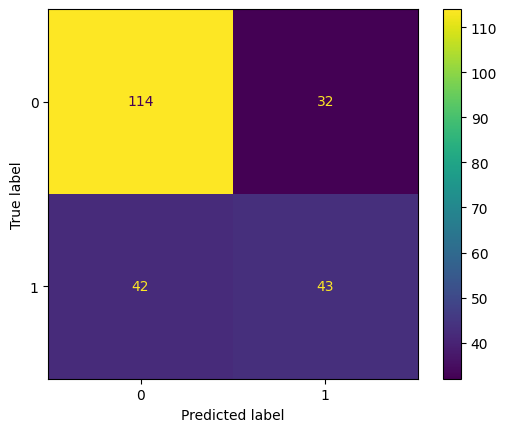

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()


/opt/homebrew/lib/python3.12/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


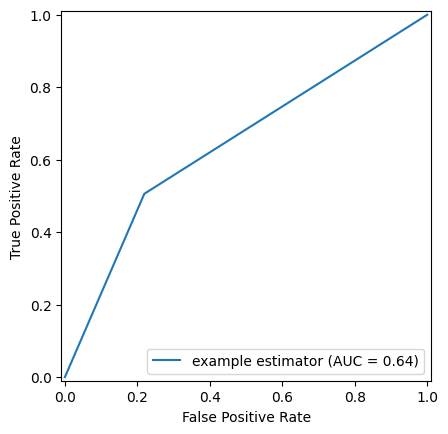

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, predictions)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()

In [11]:
!pip3 install graphviz

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 47 kB 3.2 MB/s eta 0:00:011
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [12]:
X.columns

Index(['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree'], dtype='str')

In [13]:
classes = y.unique()

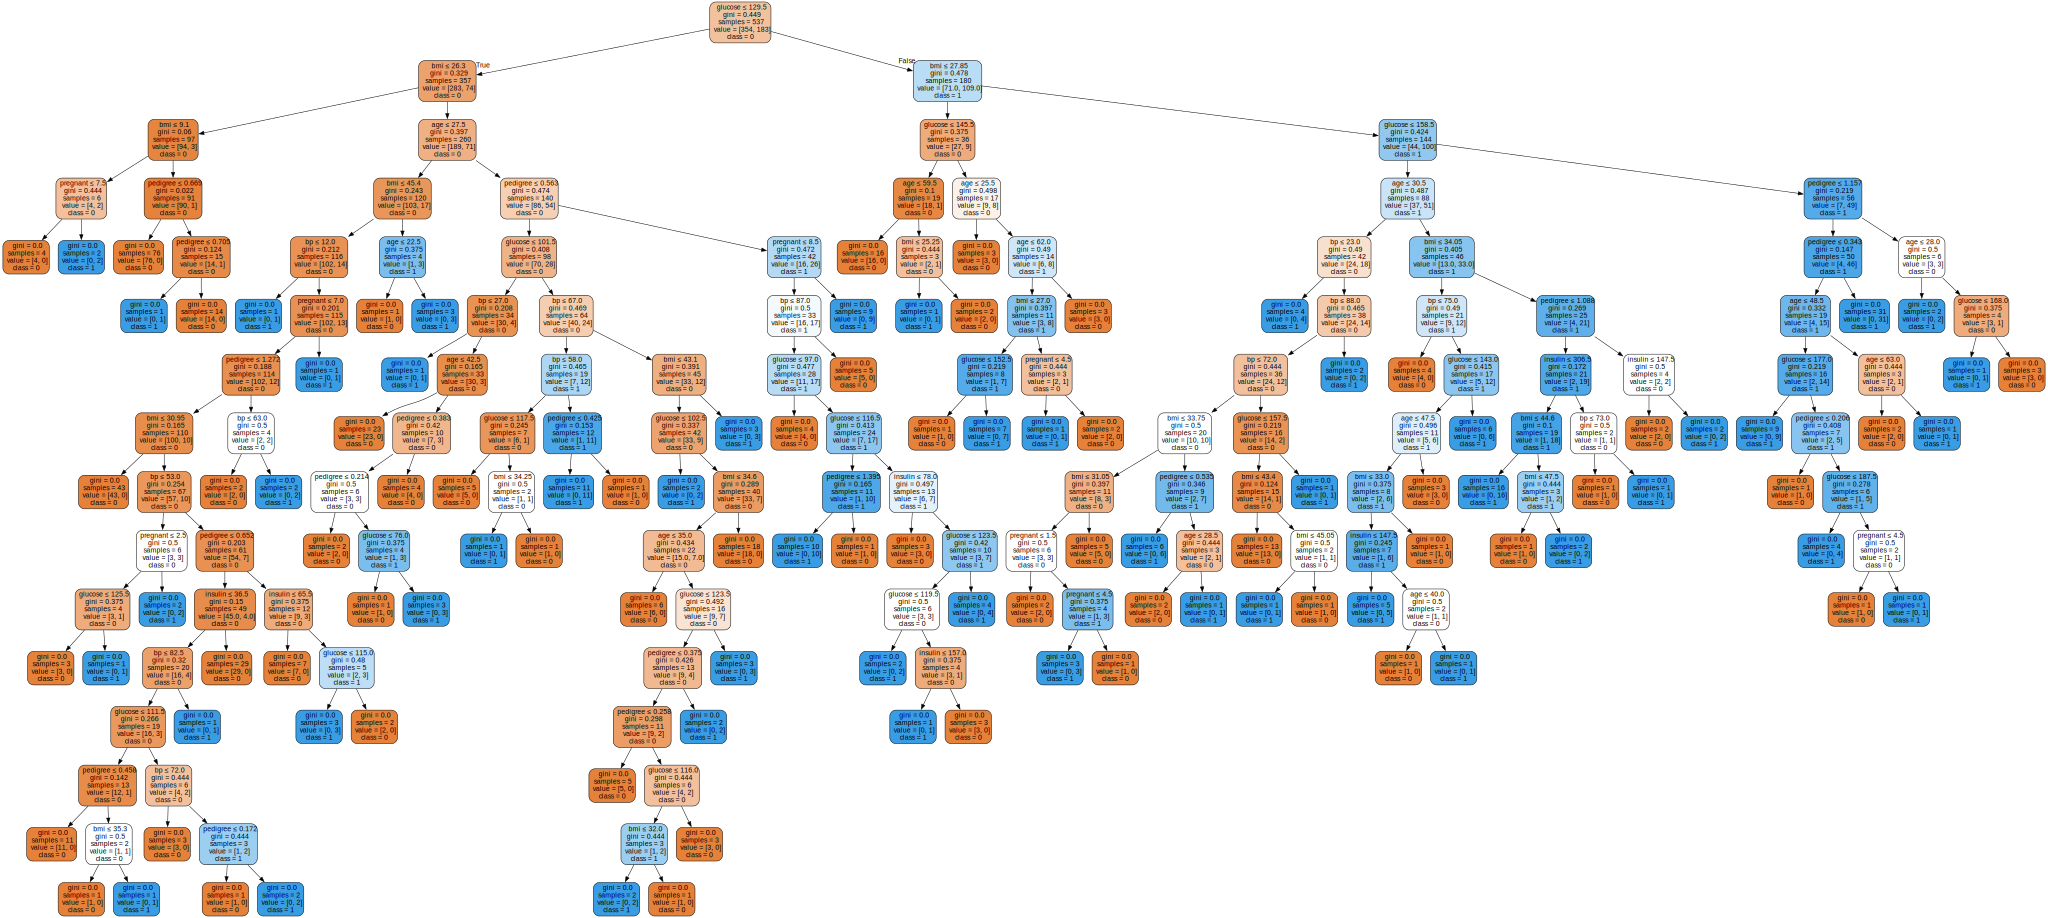

In [ ]:
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names = feature_cols,class_names=['0','1'],
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

# Excercise 1

Construct the following models on the same dataset:
- Bagging
- Random Forest
- Adaboost

Compare their performance and write a short paragraph on which one is the best. You are free to change the hyperparameters.


### Application on Cuisines Dataset

In [19]:
import pandas as pd
cuisines_df = pd.read_csv("https://raw.githubusercontent.com/a-nagar/datasets/refs/heads/main/asian_cuisines.csv")
cuisines_df.head()

,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,indian,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [20]:
cuisines_label_df = cuisines_df['cuisine']
cuisines_label_df.head()

0    indian
1    indian
2    indian
3    indian
4    indian
Name: cuisine, dtype: str

In [21]:
cuisines_label_df.value_counts()

cuisine
indian      799
thai        799
chinese     799
japanese    799
korean      799
Name: count, dtype: int64

In [22]:
cuisine_labels_distinct = cuisines_label_df.unique()

In [23]:
cuisine_labels_distinct

<ArrowStringArray>
['indian', 'thai', 'chinese', 'japanese', 'korean']
Length: 5, dtype: str

In [24]:
cuisines_feature_df = cuisines_df.drop(['cuisine'], axis=1)
cuisines_feature_df.head()

,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report, precision_recall_curve
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(cuisines_feature_df, cuisines_label_df, test_size=0.3)

In [26]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(max_depth=10)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)
predicted_probas = clf.predict_proba(X_test)

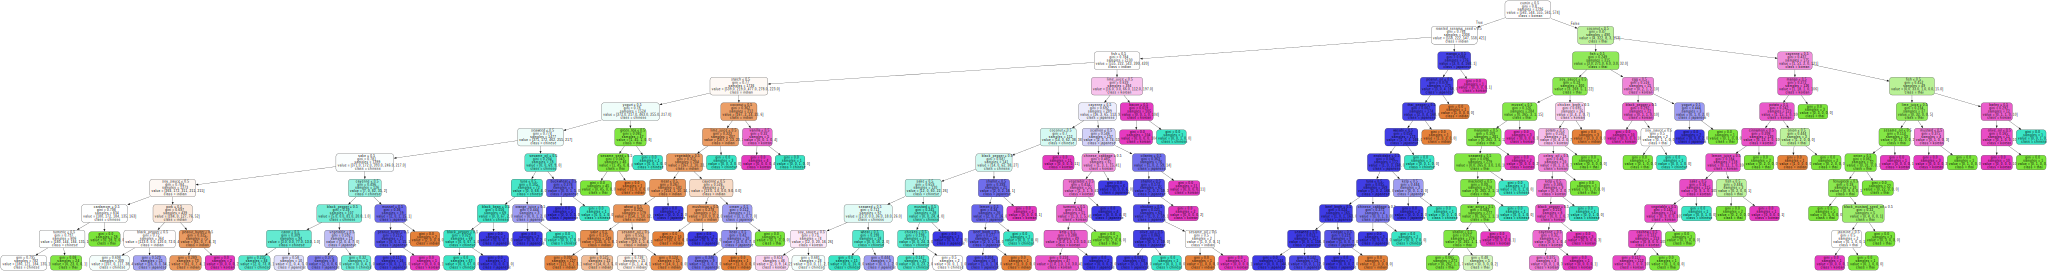

In [27]:
import graphviz
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names=cuisines_feature_df.columns,
                     class_names=cuisine_labels_distinct,
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [28]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

     chinese       0.84      0.37      0.51       237
      indian       0.95      0.73      0.82       255
    japanese       0.37      0.86      0.52       244
      korean       0.77      0.56      0.65       238
        thai       0.85      0.61      0.71       225

    accuracy                           0.63      1199
   macro avg       0.76      0.63      0.64      1199
weighted avg       0.76      0.63      0.64      1199



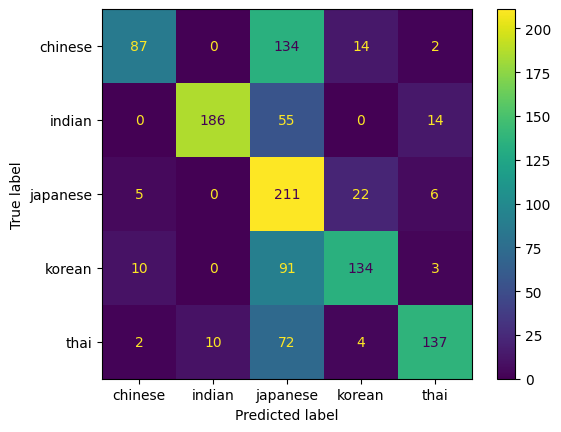

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

In [ ]:
# # Excercise 1 Solution:

# Construct the following models on the same dataset:
# - Bagging
# - Random Forest
# - Adaboost

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report   
from sklearn.tree import DecisionTreeClassifier


In [48]:
# Bagging with Dec Tree estimator  
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=0)
bagging.fit(X_train, y_train)
bagging_predictions = bagging.predict(X_test)

# Random Forest with 100 trees 
randForest = RandomForestClassifier(n_estimators=100, random_state=0)
randForest.fit(X_train, y_train)
randForest_predictions = randForest.predict(X_test)

# Adaboost with 100 trees
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),n_estimators=100, random_state=0
)
adaboost.fit(X_train, y_train)
adaboost_predictions = adaboost.predict(X_test)


In [49]:
# Print out the report of each model in respective order 

print("\t***Bagging Report*** \n ")
print(classification_report(y_test, bagging_predictions))

print("\t***Random Forest Report*** \n")
print(classification_report(y_test, randForest_predictions))

print("\t***Adaboost Report*** \n")
print(classification_report(y_test, adaboost_predictions))

	***Bagging Report*** 
 
              precision    recall  f1-score   support

     chinese       0.77      0.76      0.76       237
      indian       0.85      0.89      0.87       255
    japanese       0.82      0.82      0.82       244
      korean       0.80      0.74      0.77       238
        thai       0.79      0.83      0.81       225

    accuracy                           0.81      1199
   macro avg       0.81      0.81      0.81      1199
weighted avg       0.81      0.81      0.81      1199

	***Random Forest Report*** 

              precision    recall  f1-score   support

     chinese       0.78      0.77      0.78       237
      indian       0.90      0.94      0.92       255
    japanese       0.84      0.85      0.85       244
      korean       0.88      0.80      0.84       238
        thai       0.84      0.88      0.86       225

    accuracy                           0.85      1199
   macro avg       0.85      0.85      0.85      1199
weighted avg       0.8

# Compare their performance and write a short paragraph on which one is the best. You are free to change the hyperparameters.

According to the report, Random Forest has performed the best at 85% macro and weighted averages. This can be due to the way Random Forest maps everything out more effictively to compliment duplicate features that can potentailly be found in foods from different countries of origin - since countries can share the same ingredients. The second best was Bagging at 81% avg accuracy. This slightly fell behind since it considers all features when splitting at each node  which leads to over-fitting the model. The least accurate was Adaboost with an initial average around 67%. This model defaults to a max_depth of 1 so I configured the model and increased the max_depth field by one point at each run. It provided continuous improvement in accuracy but topped to an accuracy of 81% (similar to Bagging) where max_depth was 6. The reason why Adaboost fell behind the most can be due to a flaw in its design where it can over-optimize for instances where an ingredient is shared between different countries of origin. This limitation was brought upon by the dataset which caused each model to overfit - however, by the way Adaboost works, it overfitted the most requiring more computation power to mitigate the issue. 


# Exercise 2

The accuracy for this dataset is quite low. Can you try any other method that increases the accuracy. You can try either Random Forest or Adaboost. What do you notice?

# Parameter Grid Builder for Parameter Tuning

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

dt_pipe = Pipeline([('mms', MinMaxScaler()),
                     ('dt', DecisionTreeClassifier())])
params = [{'dt__max_depth': [3, 5, 7, 9],
         'dt__min_samples_leaf': [2, 3, 5]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(cuisines_feature_df, cuisines_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(cuisines_feature_df, cuisines_label_df))


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


{'dt__max_depth': 9, 'dt__min_samples_leaf': 3}
0.6475594493116396


In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

rf = RandomForestClassifier()

params = {'max_depth': [5, 7, 9],
          'n_estimators': [50, 100, 200],
          'max_features': ['sqrt', 'log2']
          }

grid = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(cuisines_feature_df, cuisines_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(cuisines_feature_df, cuisines_label_df))

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


{'max_depth': 9, 'max_features': 'sqrt', 'n_estimators': 100}
0.7924906132665832


In [50]:
# # Exercise 2

# The accuracy for this dataset is quite low. Can you try any other method that increases the accuracy. 
# You can try either Random Forest or Adaboost. What do you notice?

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( cuisines_feature_df, 
    cuisines_label_df, 
    test_size=0.3, 
    random_state=0
)

# Random Forest
randForest = RandomForestClassifier(n_estimators=100, 
max_depth=30,
max_features='sqrt',
random_state=0)

randForest.fit(X_train, y_train)
randForest_preds = randForest.predict(X_test)

print(f"\t***Random Forest Accuracy***\n{accuracy_score(y_test, randForest_preds):.2%}")
print()
print(classification_report(y_test, randForest_preds))

Random Forest Accuracy: 81.40%

              precision    recall  f1-score   support

     chinese       0.80      0.71      0.75       245
      indian       0.85      0.93      0.89       233
    japanese       0.71      0.86      0.78       249
      korean       0.83      0.80      0.82       222
        thai       0.91      0.78      0.84       250

    accuracy                           0.81      1199
   macro avg       0.82      0.81      0.81      1199
weighted avg       0.82      0.81      0.81      1199



After building the model and testing it, I increased the max_depth value to a top out point of 30 which produced a Rnadom Forest Accuracy of 81.40%. This is significantly higher than the Decision tree model with an accuracy of just 63%. As I construct Random Forest models, it tends to do well with preventing instances of overfitting due to the nature of the dataset. 

# Exercise 3

Try other combination of hyperparameters for Random Forest and AdaBoost models and check how good of an accuracy you can obtain. 

In [ ]:
# Random Forest
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split( cuisines_feature_df, 
    cuisines_label_df, 
    test_size=0.3, 
    random_state=0
)

params = {'max_depth': [10, 20, 30],
'n_estimators': [50, 100, 200],
'max_features': ['sqrt', 'log2']
}
randForest = RandomForestClassifier(params,random_state=0) 
gs = GridSearchCV(randForest, params, cv=5, n_jobs=-1)
gs.fit(X_train, y_train)

bestModel = gs.best_estimator_
randForest_preds = bestModel.predict(X_test)

print(f"\t***Random Forest Accuracy***\n{accuracy_score(y_test, randForest_preds)}")
print()
print(classification_report(y_test, randForest_preds))

	***Random Forest Accuracy***
0.823185988323603

              precision    recall  f1-score   support

     chinese       0.80      0.72      0.76       245
      indian       0.85      0.92      0.88       233
    japanese       0.81      0.82      0.81       249
      korean       0.84      0.78      0.81       222
        thai       0.81      0.88      0.85       250

    accuracy                           0.82      1199
   macro avg       0.82      0.82      0.82      1199
weighted avg       0.82      0.82      0.82      1199



In [68]:
# Adaboost 

from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split( cuisines_feature_df, 
    cuisines_label_df, 
    test_size=0.3, 
    random_state=0
)

ada_params = {'estimator__max_depth': [1, 2, 4],
'n_estimators': [50, 100, 200],
'learning_rate': [0.5, 1.0, 1.5]
}

adaBoost = AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=0)
gs = GridSearchCV(adaBoost, ada_params, cv=5, n_jobs=-1)
gs.fit(X_train, y_train)

bestModelAda = gs.best_estimator_
adaboost_preds= bestModelAda.predict(X_test)

print(f"\t***AdaBoost Accuracy***\n{accuracy_score(y_test, adaboost_preds)}")
print()
print(classification_report(y_test, adaboost_preds))

	***AdaBoost Accuracy***
0.7823185988323603

              precision    recall  f1-score   support

     chinese       0.73      0.70      0.72       245
      indian       0.87      0.86      0.87       233
    japanese       0.77      0.78      0.77       249
      korean       0.82      0.77      0.79       222
        thai       0.73      0.80      0.77       250

    accuracy                           0.78      1199
   macro avg       0.79      0.78      0.78      1199
weighted avg       0.78      0.78      0.78      1199

